In [1]:
!pip install matplotlib pandas

Lab Task 1
BFS on Tree: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
DFS on Tree: [0, 1, 3, 7, 8, 4, 9, 2, 5, 10, 6, 11, 12]
BFS on Graph: ['A', 'B', 'C', 'D', 'E', 'F']
DFS on Graph: ['A', 'B', 'D', 'E', 'F', 'C']
Lab Task 2
Size: 1000 | BFS: 0.000461s | DFS: 0.000218s
Size: 40000 | BFS: 0.294195s | DFS: 0.020832s
Size: 80000 | BFS: 0.221185s | DFS: 0.028445s
Size: 200000 | BFS: 0.244602s | DFS: 0.080699s
Size: 1000000 | BFS: 1.329486s | DFS: 0.317922s
 Tree Size  BFS TIME  DFS TIME
      1000  0.000461  0.000218
     40000  0.294195  0.020832
     80000  0.221185  0.028445
    200000  0.244602  0.080699
   1000000  1.329486  0.317922


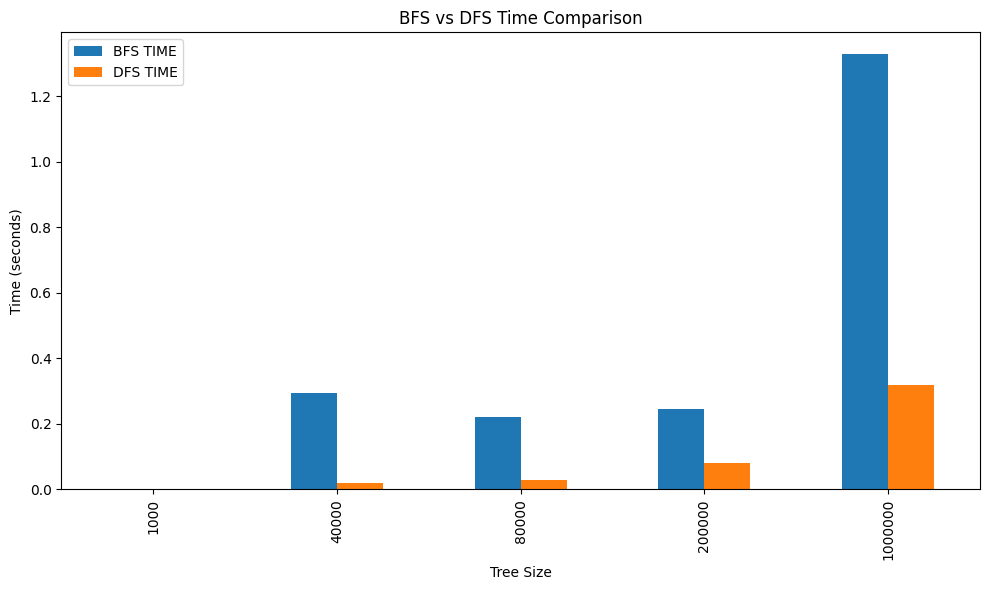

Lab Task 3
Shortest Route: Islamabad -> Rawalpindi -> Quetta -> Karachi
Total Cities Travelled: 4


In [14]:
Lab Task 1

import collections

tree = {
    0: [1, 2],
    1: [3, 4],
    2: [5, 6],
    3: [7, 8],
    4: [9],
    5: [10],
    6: [11, 12],
    7: [], 8: [], 9: [], 10: [], 11: [], 12: []
}

def bfs(graph, start):
    visited = set()
    queue = collections.deque([start])
    visited.add(start)
    traversal = []
    while queue:
        node = queue.popleft()
        traversal.append(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return traversal

def dfs(graph, start, visited=None):
    if visited is None:
        visited = set()
    visited.add(start)
    traversal = [start]
    for neighbor in graph[start]:
        if neighbor not in visited:
            traversal += dfs(graph, neighbor, visited)
    return traversal

print("BFS on Tree:", bfs(tree, 0))
print("DFS on Tree:", dfs(tree, 0))

graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

print("BFS on Graph:", bfs(graph, 'A'))
print("DFS on Graph:", dfs(graph, 'A'))


Lab Task 2

import random
import time
import pandas as pd
import matplotlib.pyplot as plt

def bfs_search(data_list, goal):
    graph = {i: [] for i in range(len(data_list))}
    for i in range(len(data_list) - 1):
        graph[i].append(i + 1)
    visited = set()
    queue = collections.deque([0])
    visited.add(0)
    while queue:
        node = queue.popleft()
        if data_list[node] == goal:
            return node
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return -1

def dfs_iterative(data_list, goal, graph):
    visited = set()
    stack = [0]
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        if data_list[node] == goal:
            return node
        for neighbor in reversed(graph[node]):
            if neighbor not in visited:
                stack.append(neighbor)
    return -1

sizes = [1000, 40000, 80000, 200000, 1000000]
result = []

for s in sizes:
    data = random.sample(range(1, s * 10), s)
    goal = data[s - 220]

    graph = {i: [] for i in range(s)}
    for i in range(s - 1):
        graph[i].append(i + 1)

    start_time = time.time()
    bfs_search(data, goal)
    bfs_duration = time.time() - start_time

    start_time = time.time()
    dfs_iterative(data, goal, graph)
    dfs_duration = time.time() - start_time

    result.append({"Tree Size": s, "BFS TIME": bfs_duration, "DFS TIME": dfs_duration})
    print(f"Size: {s} | BFS: {bfs_duration:.6f}s | DFS: {dfs_duration:.6f}s")

df = pd.DataFrame(result)
print(df.to_string(index=False))

df.plot(x="Tree Size", y=["BFS TIME", "DFS TIME"], kind="bar", figsize=(10, 6))
plt.title("BFS vs DFS Time Comparison")
plt.xlabel("Tree Size")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()


Lab Task 3

pak_graph = {
    'Islamabad':  ['Rawalpindi', 'Lahore', 'Peshawar'],
    'Rawalpindi': ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar':   ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore':     ['Islamabad', 'Multan', 'Quetta'],
    'Multan':     ['Lahore', 'Karachi', 'Quetta'],
    'Quetta':     ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi':    ['Multan', 'Quetta']
}

def find_shortest_route(graph, start, goal):
    queue = collections.deque([[start]])
    visited = {start}
    while queue:
        path = queue.popleft()
        city = path[-1]
        if city == goal:
            return path
        for neighbor in graph.get(city, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])
    return None

short = find_shortest_route(pak_graph, 'Islamabad', 'Karachi')
print("Shortest Route:", " -> ".join(short))
print("Total Cities Travelled:", len(short))